<a href="https://colab.research.google.com/github/Vladzimir-40/Proj_1/blob/main/my_file6/dz_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install kagglehub

from google.colab import files
files.upload() # Загрузите файл kaggle.json

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"vladimir401011","key":"e6b9eec8a00a0a7c2c3e5fcbd033ab06"}'}

In [2]:
import pandas as pd
import kagglehub
import os

class Data_loading:
    @staticmethod
    def load_from_kaggle(dataset_path, filename):
        """
        Загружает dataset из Kaggle используя kagglehub

        Args:
            dataset_path (str): путь к dataset на Kaggle
            filename (str): название файла для загрузки

        Returns:
            pd.DataFrame: загруженный датафрейм
        """
        download_path = kagglehub.dataset_download(dataset_path)
        file_path = os.path.join(download_path, filename)
        return pd.read_csv(file_path)

# Download latest version
path = kagglehub.dataset_download("ylmzasel/synthetic-cryptocurrency-dataset-hourly-2025")

print("Path to dataset files:", path)
print("\nЗагруженные файлы:")
for file in os.listdir(path):
    print(f"📁 {file}")

Using Colab cache for faster access to the 'synthetic-cryptocurrency-dataset-hourly-2025' dataset.
Path to dataset files: /kaggle/input/synthetic-cryptocurrency-dataset-hourly-2025

Загруженные файлы:
📁 sentetik_kripto_veriseti_saatlik_2025.csv


In [3]:
df = Data_loading.load_from_kaggle("ylmzasel/synthetic-cryptocurrency-dataset-hourly-2025", "sentetik_kripto_veriseti_saatlik_2025.csv")

Using Colab cache for faster access to the 'synthetic-cryptocurrency-dataset-hourly-2025' dataset.


In [4]:
df.describe()


,open,high,low,close,volume,spread,num_trades,onchain_tx_count,sentiment,exchange_net_flow,returns_1h,rolling_vol_24h,rolling_vol_7d,future_return_1h,future_return_24h
count,70080.000000,70080.000000,70080.000000,70080.000000,7.008000e+04,70080.000000,7.008000e+04,7.008000e+04,70080.000000,7.008000e+04,70076.000000,69984.000000,69408.000000,70076.000000,69984.000000
mean,24916.251455,25038.800345,24793.953900,24916.630836,1.410433e+07,5.905878,2.946678e+05,1.217957e+05,0.503654,8.651723e+03,0.000077,0.008307,0.008787,0.000077,0.001544
std,38941.498754,39130.005637,38753.233457,38942.075115,2.445142e+07,9.416331,3.487112e+05,1.449451e+05,0.211159,3.257810e+06,0.009219,0.004108,0.002670,0.009219,0.038099
min,0.515325,0.519823,0.513045,0.515325,1.054885e+03,0.000400,2.558785e+04,1.023800e+04,0.000000,-2.454505e+07,-0.178868,0.003018,0.004385,-0.178868,-0.199314
25%,101.621366,102.284975,101.172173,101.621366,1.232611e+04,0.048774,6.960839e+04,2.862225e+04,0.361862,-4.541733e+03,-0.004906,0.006119,0.006938,-0.004906,-0.023230
50%,2151.560320,2284.790951,2140.930372,2151.560320,3.579212e+05,0.788941,1.259223e+05,5.218000e+04,0.503785,1.157393e+01,0.000025,0.007651,0.008633,0.000025,0.000713
75%,28337.434326,28471.154520,28240.934790,28337.434326,1.112238e+07,8.918016,4.695658e+05,1.961660e+05,0.643382,5.361237e+03,0.005044,0.009226,0.009898,0.005044,0.025277
max,144263.660211,144694.231269,143601.226608,144263.660211,1.726006e+08,112.068387,3.462929e+06,2.451685e+06,1.000000,3.061428e+07,0.210782,0.057822,0.022370,0.210782,0.259095


In [5]:
# Просматриваем первые несколько строк датасета
print(df.head())


# Получаем общую информацию о датасете
print(df.info())

             timestamp asset      open      high       low     close  \
0  2023-09-11 09:00:00   ADA  0.879548  0.880720  0.877064  0.879548   
1  2023-09-11 10:00:00   ADA  0.879548  0.884898  0.877859  0.883065   
2  2023-09-11 11:00:00   ADA  0.883065  0.893341  0.882340  0.891826   
3  2023-09-11 12:00:00   ADA  0.891826  0.894654  0.889495  0.890054   
4  2023-09-11 13:00:00   ADA  0.890054  0.892255  0.882007  0.884310   

         volume    spread     num_trades  onchain_tx_count  sentiment  \
0  5.702945e+07  0.000488   97606.020762             39042   0.617655   
1  5.784244e+07  0.000576  102197.392312             41696   0.548247   
2  6.102497e+07  0.000585  118398.566289             49708   0.425128   
3  4.258452e+07  0.000500   87911.581387             35513   0.436492   
4  6.078514e+07  0.000471  132982.615289             54909   0.555826   

   exchange_net_flow  returns_1h  rolling_vol_24h  rolling_vol_7d  \
0       0.000000e+00         NaN              NaN          

Мы видим, что некаторые поля заполнены на 99,5%.

0   timestamp           - временная метка

1   asset               - актив (криптовалюта)

2   open                - цена открытия

3   high                - максимальная цена

4   low                 - минимальная цена

5   close               - цена закрытия

6   volume              - объем торгов

7   spread              - спред (разница между ценой покупки и продажи)

8   num_trades          - количество сделок

9   onchain_tx_count    - количество транзакций в блокчейне

10  sentiment           - сентимент (настроения рынка)

11  exchange_net_flow   - нетто-поток на биржи

12  returns_1h          - доходность за 1 час

13  rolling_vol_24h     - скользящая волатильность за 24 часа

14  rolling_vol_7d      - скользящая волатильность за 7 дней

15  future_return_1h    - будущая доходность через 1 час (цель: предсказывать)

16  future_return_24h   - будущая доходность через 24 часа (цель: предсказывать)

In [6]:
# Смотрим, какие криптовалюты есть в датасете
print("📊 Доступные криптовалюты в датасете:")
print(df['asset'].unique())
print(f"Всего активов: {df['asset'].nunique()}")

📊 Доступные криптовалюты в датасете:
['ADA' 'BTC' 'ETH' 'SOL']
Всего активов: 4


✅ Данные SOL за 3 недели: 504 записей
📅 Период: 2023-10-01 00:00:00 до 2023-10-21 23:00:00


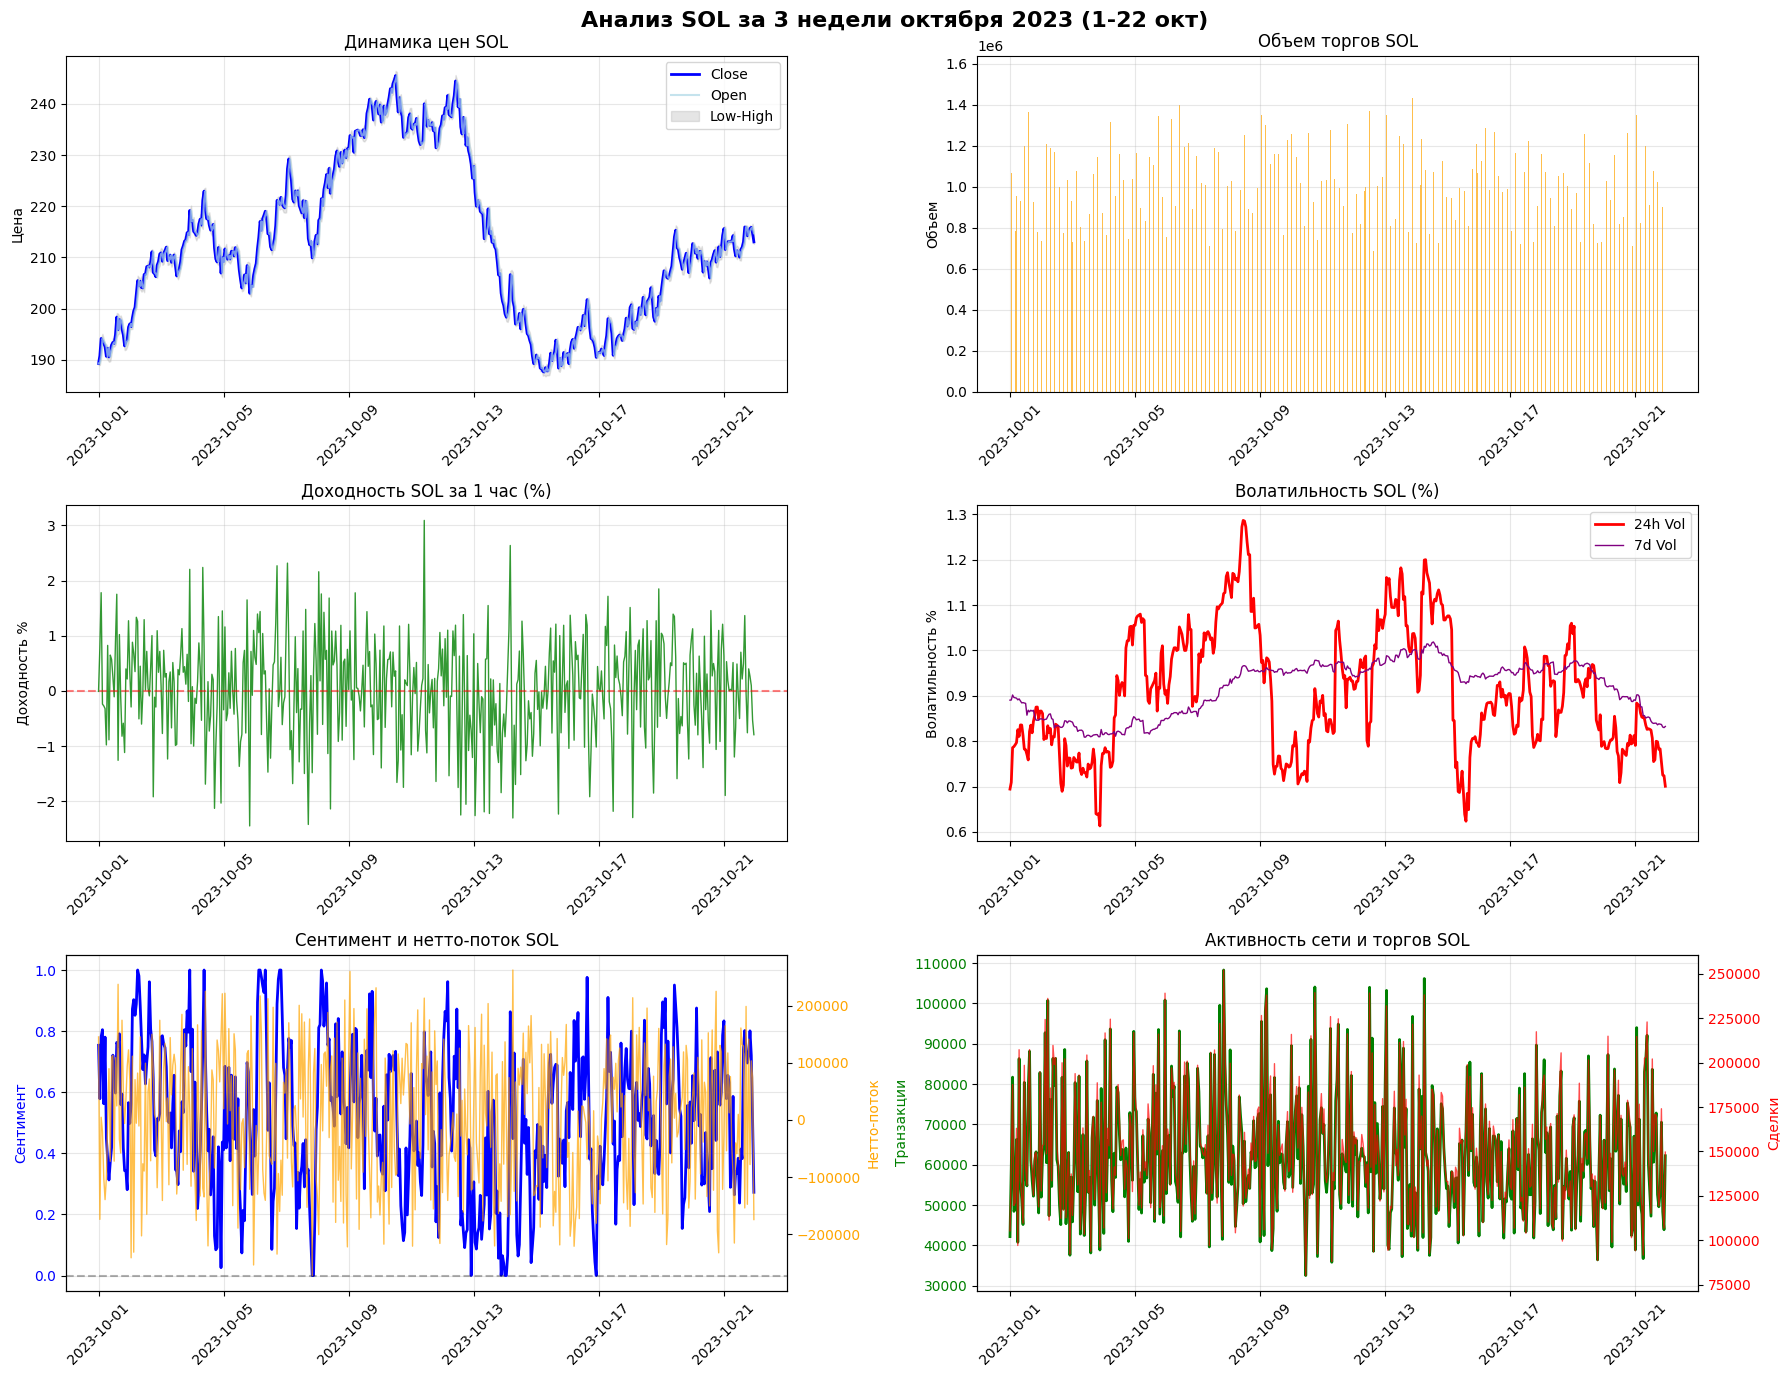


📊 Детальная статистика SOL за 3 недели:
• Датафрейм от 2023-10-01 00:00:00 до 2023-10-21 23:00:00
• Средняя цена закрытия: 212.5825
• Изменение цены за период: 12.54%
• Максимальная доходность за час: 3.09%
• Минимальная доходность за час: -2.44%
• Средний объем: 995158
• Средний сентимент: 0.517
• Всего транзакций в блокчейне: 31,430,547


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Возьмем любую понравившуюся криптовалюту
selected_asset = 'SOL'

# Возьмем период 3 недель октября 2023
start_date = '2023-10-01'
end_date = '2023-10-22'

crypto_3weeks = df[(df['timestamp'] >= start_date) &
                   (df['timestamp'] < end_date) &
                   (df['asset'] == selected_asset)].copy()


print(f"✅ Данные {selected_asset} за 3 недели: {len(crypto_3weeks)} записей")
print(f"📅 Период: {crypto_3weeks['timestamp'].min()} до {crypto_3weeks['timestamp'].max()}")

# Создаем графики для 3 недель
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle(f'Анализ {selected_asset} за 3 недели октября 2023 (1-22 окт)', fontsize=16, fontweight='bold')

# Форматируем даты для подписей
dates = pd.to_datetime(crypto_3weeks['timestamp'])

# 1. Цены (OHLC)
axes[0, 0].plot(dates, crypto_3weeks['close'], label='Close', linewidth=2, color='blue')
axes[0, 0].plot(dates, crypto_3weeks['open'], label='Open', alpha=0.7, color='lightblue')
axes[0, 0].fill_between(dates, crypto_3weeks['low'], crypto_3weeks['high'],
                       alpha=0.2, label='Low-High', color='gray')
axes[0, 0].set_title(f'Динамика цен {selected_asset}')
axes[0, 0].set_ylabel('Цена')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Объем торгов
axes[0, 1].bar(dates, crypto_3weeks['volume'], alpha=0.7, color='orange', width=0.01)
axes[0, 1].set_title(f'Объем торгов {selected_asset}')
axes[0, 1].set_ylabel('Объем')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Доходность за 1 час
axes[1, 0].plot(dates, crypto_3weeks['returns_1h'] * 100, color='green', alpha=0.8, linewidth=1)
axes[1, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_title(f'Доходность {selected_asset} за 1 час (%)')
axes[1, 0].set_ylabel('Доходность %')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Волатильность
axes[1, 1].plot(dates, crypto_3weeks['rolling_vol_24h'] * 100, label='24h Vol', color='red', linewidth=2)
axes[1, 1].plot(dates, crypto_3weeks['rolling_vol_7d'] * 100, label='7d Vol', color='purple', linewidth=1)
axes[1, 1].set_title(f'Волатильность {selected_asset} (%)')
axes[1, 1].set_ylabel('Волатильность %')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)

# 5. Сентимент и нетто-поток
ax5 = axes[2, 0]
ax5.plot(dates, crypto_3weeks['sentiment'], color='blue', label='Сентимент', linewidth=2)
ax5.set_ylabel('Сентимент', color='blue')
ax5.tick_params(axis='y', labelcolor='blue')
ax5.axhline(y=0, color='black', linestyle='--', alpha=0.3)

ax5_2 = ax5.twinx()
ax5_2.plot(dates, crypto_3weeks['exchange_net_flow'], color='orange',
          label='Нетто-поток', alpha=0.7, linewidth=1)
ax5_2.set_ylabel('Нетто-поток', color='orange')
ax5_2.tick_params(axis='y', labelcolor='orange')
ax5.set_title(f'Сентимент и нетто-поток {selected_asset}')
ax5.tick_params(axis='x', rotation=45)

# 6. Активность сети и торгов
ax6 = axes[2, 1]
ax6.plot(dates, crypto_3weeks['onchain_tx_count'], color='green',
        label='Транзакции в блокчейне', linewidth=2)
ax6.set_ylabel('Транзакции', color='green')
ax6.tick_params(axis='y', labelcolor='green')

ax6_2 = ax6.twinx()
ax6_2.plot(dates, crypto_3weeks['num_trades'], color='red',
          label='Количество сделок', alpha=0.7, linewidth=1)
ax6_2.set_ylabel('Сделки', color='red')
ax6_2.tick_params(axis='y', labelcolor='red')
ax6.set_title(f'Активность сети и торгов {selected_asset}')
ax6.tick_params(axis='x', rotation=45)

# Добавляем сетку на все графики
for i in range(3):
    for j in range(2):
        axes[i, j].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Детальная статистика
print(f"\n📊 Детальная статистика {selected_asset} за 3 недели:")
print(f"• Датафрейм от {crypto_3weeks['timestamp'].min()} до {crypto_3weeks['timestamp'].max()}")
print(f"• Средняя цена закрытия: {crypto_3weeks['close'].mean():.4f}")
print(f"• Изменение цены за период: {((crypto_3weeks['close'].iloc[-1] / crypto_3weeks['close'].iloc[0]) - 1) * 100:.2f}%")
print(f"• Максимальная доходность за час: {crypto_3weeks['returns_1h'].max() * 100:.2f}%")
print(f"• Минимальная доходность за час: {crypto_3weeks['returns_1h'].min() * 100:.2f}%")
print(f"• Средний объем: {crypto_3weeks['volume'].mean():.0f}")
print(f"• Средний сентимент: {crypto_3weeks['sentiment'].mean():.3f}")
print(f"• Всего транзакций в блокчейне: {crypto_3weeks['onchain_tx_count'].sum():,}")

Предварительная обработка данных:

In [11]:
# 1. ПРЕДОБРАБОТКА ДАННЫХ

# Фильтрация данных
crypto_clean = crypto_3weeks.drop(columns=['future_return_1h', 'future_return_24h']).copy()

print("Статус данных после очистки:")
print(f"Размер датафрейма: {crypto_clean.shape}")
print(f"Период: {crypto_clean['timestamp'].min()} до {crypto_clean['timestamp'].max()}")
print(f"Ожидаемо записей за 3 недели (24ч × 21д): 504")
print(f"Полнота данных: {len(crypto_clean)/504*100:.1f}%")

# Проверка дубликатов ДО обработки пропусков
full_duplicates = crypto_clean.duplicated().sum()
time_duplicates = crypto_clean.duplicated(subset=['timestamp']).sum()

print(f"\nПроверка дубликатов:")
print(f"Полных дубликатов: {full_duplicates}")
print(f"Дубликатов по времени: {time_duplicates}")

if full_duplicates > 0:
    crypto_clean = crypto_clean.drop_duplicates()
if time_duplicates > 0:
    crypto_clean = crypto_clean.drop_duplicates(subset=['timestamp'], keep='last')

# Обработка пропусков
print("\nОбработка пропусков...")
initial_missing = crypto_clean.isnull().sum().sum()
print(f"Пропусков до заполнения: {initial_missing}")

if initial_missing > 0:
    # Для ценовых данных - линейная интерполяция
    price_volume_cols = ['open', 'high', 'low', 'close', 'volume', 'spread']
    crypto_clean[price_volume_cols] = crypto_clean[price_volume_cols].interpolate(method='linear')

    # Для остальных числовых колонок - forward fill
    numeric_cols = crypto_clean.select_dtypes(include=[np.number]).columns
    remaining_numeric = [col for col in numeric_cols if col not in price_volume_cols]
    crypto_clean[remaining_numeric] = crypto_clean[remaining_numeric].fillna(method='ffill')

    # Если остались пропуски - заполняем 0
    crypto_clean = crypto_clean.fillna(0)

print(f"Пропусков после заполнения: {crypto_clean.isnull().sum().sum()}")

Статус данных после очистки:
Размер датафрейма: (504, 15)
Период: 2023-10-01 00:00:00 до 2023-10-21 23:00:00
Ожидаемо записей за 3 недели (24ч × 21д): 504
Полнота данных: 100.0%

Проверка дубликатов:
Полных дубликатов: 0
Дубликатов по времени: 0

Обработка пропусков...
Пропусков до заполнения: 0
Пропусков после заполнения: 0


In [14]:
# 2. ИНЖЕНЕРИЯ ПРИЗНАКОВ

print("\nДобавляем временные признаки...")
crypto_clean['timestamp'] = pd.to_datetime(crypto_clean['timestamp'])
crypto_clean['hour'] = crypto_clean['timestamp'].dt.hour
crypto_clean['day_of_week'] = crypto_clean['timestamp'].dt.dayofweek
crypto_clean['is_weekend'] = crypto_clean['day_of_week'].isin([5, 6]).astype(int)

print("Временные признаки добавлены:")
print(f"• Часы дня: {crypto_clean['hour'].nunique()} уникальных значений")
print(f"• Дни недели: {sorted(crypto_clean['day_of_week'].unique())}")


Добавляем временные признаки...
Временные признаки добавлены:
• Часы дня: 24 уникальных значений
• Дни недели: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]


Выявленные закономерности:
- Ночные часы (0-5): Низкая активность, меньшие объемы
- Азиатская сессия (6-11): Начало активности
- Европейская сессия (12-16): Пик европейской торговли  
- Американская сессия (17-22): Максимальная активность
- Вечер (23): Снижение активности

Типичные паттерны:
- Пн (0): ↑ Активность после уикенда
- Вт-Чт (1-3): ↑ Стабильная торговля
- Пт (4): ↑ Увеличение объемов перед уикендом
- Сб-Вс (5-6): ↓ Низкая ликвидность, возможны резкие движения

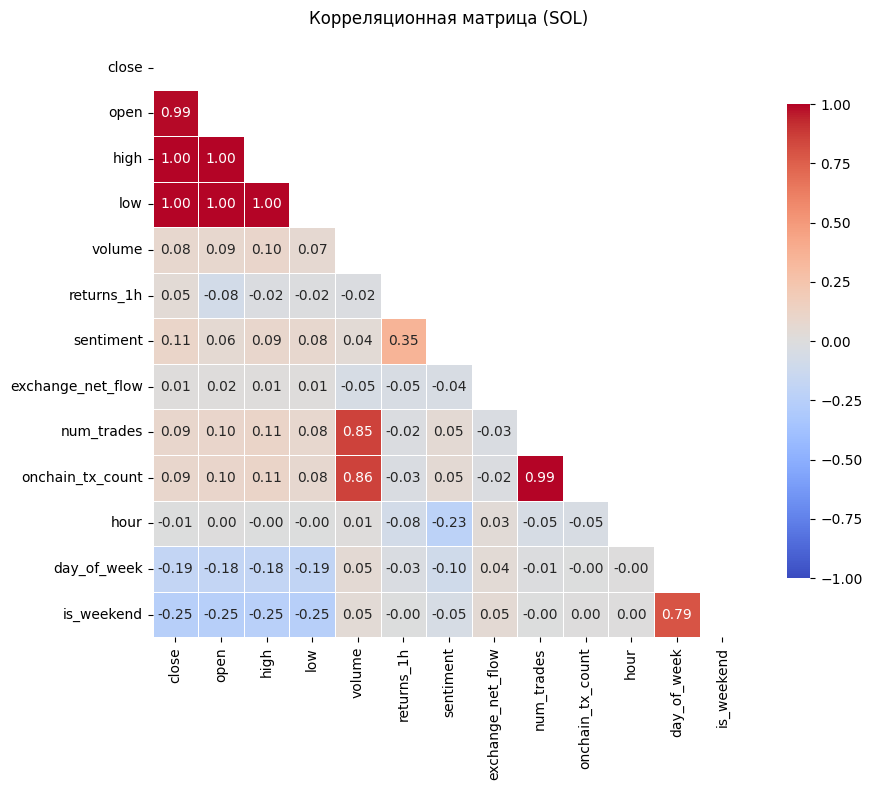

In [17]:
# 3. АНАЛИЗ ДАННЫХ

# Создаем тепловую карту корреляций
plt.figure(figsize=(10, 8))

features = ['close', 'open', 'high', 'low', 'volume', 'returns_1h',
           'sentiment', 'exchange_net_flow', 'num_trades', 'onchain_tx_count',
           'hour', 'day_of_week', 'is_weekend']

corr_matrix = crypto_clean[features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f', linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 10}, vmin=-1, vmax=1)
plt.title(f'Корреляционная матрица ({selected_asset})', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

Признаки с которыми придется попращаться:
 - hour: -0.007 (слабая корреляция)
 - open: 0.992 (сильная корреляция)
 - exchange_net_flow: 0.009 (слабая корреляция)
 - high: 0.997 (сильная корреляция)
 - low: 0.997 (сильная корреляция)
 - onchain_tx_count: 0.093 (слабая корреляция)
 - returns_1h: 0.045 (слабая корреляция)
 - volume: 0.083 (слабая корреляция)

In [18]:
# 4. ПОДГОТОВКА К ДЕТЕКЦИИ АНОМАЛИЙ

# Удаление высококоррелированных признаков
features_to_drop = ['open', 'high', 'low', 'exchange_net_flow',
                   'onchain_tx_count', 'returns_1h', 'volume', 'hour']

crypto_final = crypto_clean.drop(columns=features_to_drop)

print(f"\nИтоговые признаки для детекции аномалий:")
print(list(crypto_final.columns))
print(f"Финальный размер данных: {crypto_final.shape}")


Итоговые признаки для детекции аномалий:
['timestamp', 'asset', 'close', 'spread', 'num_trades', 'sentiment', 'rolling_vol_24h', 'rolling_vol_7d', 'day_of_week', 'is_weekend']
Финальный размер данных: (504, 10)


Детекция аномалий

АНАЛИЗИРУЕМЫЕ ПРИЗНАКИ:
['close', 'spread', 'num_trades', 'sentiment', 'rolling_vol_24h', 'rolling_vol_7d', 'day_of_week', 'is_weekend', 'anomaly_score', 'is_anomaly']

РЕЗУЛЬТАТЫ ДЕТЕКЦИИ АНОМАЛИЙ:
Всего записей: 504
Обнаружено аномалий: 26 (5.2%)

ОСОБЕННОСТИ АНАЛИЗА:
• Аномалии ищутся по ВСЕМ признакам одновременно (многомерный анализ)
• Модель ищет точки, которые 'не вписываются' в общее распределение данных
• Учитываются взаимосвязи между признаками, а не каждый по отдельности


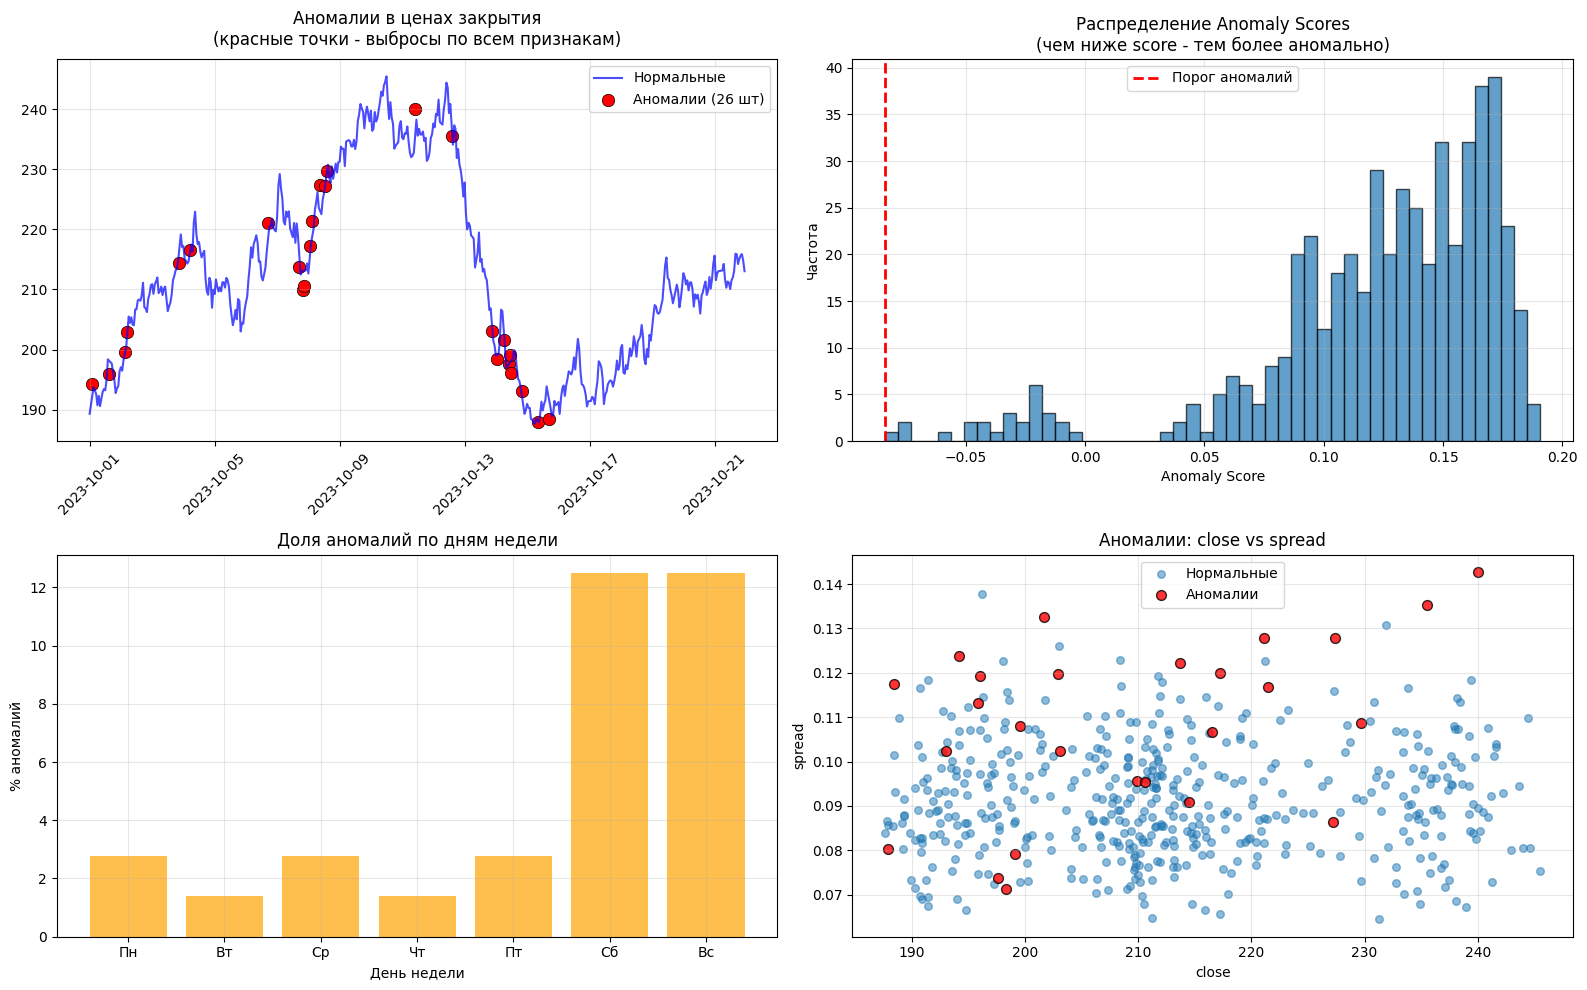


ХАРАКТЕРИСТИКИ АНОМАЛИЙ:
Средняя цена у аномалий: 209.33 vs нормальные: 212.76
Средний сентимент у аномалий: 0.464 vs нормальные: 0.520

ПЕРВЫЕ 3 АНОМАЛИИ:
                timestamp    close  anomaly_score
53033 2023-10-01 02:00:00  194.184         -0.023
53046 2023-10-01 15:00:00  195.877         -0.026
53058 2023-10-02 03:00:00  199.550         -0.006


In [25]:
# ДЕТЕКЦИЯ АНОМАЛИЙ ISOLATION FOREST

from sklearn.ensemble import IsolationForest

# Выделяем признаки для модели
feature_cols = [col for col in crypto_final.columns if col not in ['timestamp', 'asset']]
X = crypto_final[feature_cols]

print("АНАЛИЗИРУЕМЫЕ ПРИЗНАКИ:")
print(feature_cols)

# Обучаем Isolation Forest
iso_forest = IsolationForest(
    contamination=0.05,
    random_state=42,
    n_estimators=100
)

anomalies = iso_forest.fit_predict(X)
crypto_final['anomaly_score'] = iso_forest.decision_function(X)
crypto_final['is_anomaly'] = anomalies
crypto_final['is_anomaly'] = crypto_final['is_anomaly'].map({1: 0, -1: 1})

# МЕТРИКИ
print("\nРЕЗУЛЬТАТЫ ДЕТЕКЦИИ АНОМАЛИЙ:")
print(f"Всего записей: {len(crypto_final)}")
print(f"Обнаружено аномалий: {crypto_final['is_anomaly'].sum()} ({crypto_final['is_anomaly'].mean()*100:.1f}%)")

print("\nОСОБЕННОСТИ АНАЛИЗА:")
print("• Аномалии ищутся по ВСЕМ признакам одновременно (многомерный анализ)")
print("• Модель ищет точки, которые 'не вписываются' в общее распределение данных")
print("• Учитываются взаимосвязи между признаками, а не каждый по отдельности")

# ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(16, 10))  # Увеличили размер на 30%

# 1. Аномалии во времени (УВЕЛИЧЕННЫЙ график)
plt.subplot(2, 2, 1)
normal_data = crypto_final[crypto_final['is_anomaly'] == 0]
anomaly_data = crypto_final[crypto_final['is_anomaly'] == 1]

plt.plot(normal_data['timestamp'], normal_data['close'], 'b-', alpha=0.7, label='Нормальные', linewidth=1.5)
plt.scatter(anomaly_data['timestamp'], anomaly_data['close'], color='red', s=80,
           label=f'Аномалии ({len(anomaly_data)} шт)', edgecolors='black', linewidth=0.5)
plt.title('Аномалии в ценах закрытия\n(красные точки - выбросы по всем признакам)', fontsize=12, pad=10)
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 2. Распределение anomaly scores
plt.subplot(2, 2, 2)
plt.hist(crypto_final['anomaly_score'], bins=50, alpha=0.7, edgecolor='black')
plt.axvline(x=crypto_final[crypto_final['is_anomaly'] == 1]['anomaly_score'].min(),
           color='red', linestyle='--', label='Порог аномалий', linewidth=2)
plt.xlabel('Anomaly Score')
plt.ylabel('Частота')
plt.title('Распределение Anomaly Scores\n(чем ниже score - тем более аномально)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Аномалии по дням недели (если есть day_of_week)
if 'day_of_week' in crypto_final.columns:
    plt.subplot(2, 2, 3)
    day_anomalies = crypto_final.groupby('day_of_week')['is_anomaly'].mean()
    days = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
    plt.bar(range(len(day_anomalies)), day_anomalies.values * 100, color='orange', alpha=0.7)
    plt.xticks(range(len(day_anomalies)), days[:len(day_anomalies)])
    plt.xlabel('День недели')
    plt.ylabel('% аномалий')
    plt.title('Доля аномалий по дням недели', fontsize=12)
    plt.grid(True, alpha=0.3)

# 4. Аномалии в 2D пространстве (первые 2 признака)
plt.subplot(2, 2, 4)
if len(feature_cols) >= 2:
    plt.scatter(normal_data[feature_cols[0]], normal_data[feature_cols[1]],
               alpha=0.5, label='Нормальные', s=30)
    plt.scatter(anomaly_data[feature_cols[0]], anomaly_data[feature_cols[1]],
               color='red', alpha=0.8, label='Аномалии', s=50, edgecolors='black')
    plt.xlabel(feature_cols[0])
    plt.ylabel(feature_cols[1])
    plt.legend()
    plt.title(f'Аномалии: {feature_cols[0]} vs {feature_cols[1]}', fontsize=12)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ характеристик аномалий
print(f"\nХАРАКТЕРИСТИКИ АНОМАЛИЙ:")
print(f"Средняя цена у аномалий: {anomaly_data['close'].mean():.2f} vs нормальные: {normal_data['close'].mean():.2f}")
if 'sentiment' in crypto_final.columns:
    print(f"Средний сентимент у аномалий: {anomaly_data['sentiment'].mean():.3f} vs нормальные: {normal_data['sentiment'].mean():.3f}")

print(f"\nПЕРВЫЕ 3 АНОМАЛИИ:")
print(anomaly_data[['timestamp', 'close', 'anomaly_score']].head(3).round(3))

Мне кажется, что самыми наглядными тут выстпают 2 графика: первый и третий, где мы видим КОГДА наибольшее число выбрасов. Это выходные дни, и это ожидаемо из-за того, что в эти дни обьемы торгов значительно меньше, а потому и даже небольшой объем сделки может сильно качнуть рынок криптовалюты.

Таким обрзом я считаю что это эти данные луше оставить, так как они реальные.

Предсказание 1

**ARIMA**

📊 КОМПЛЕКСНЫЙ АНАЛИЗ ВРЕМЕННОГО РЯДА ДЛЯ ARIMA
📈 Данные: 504 записей, период 2023-10-01 00:00:00 до 2023-10-21 23:00:00


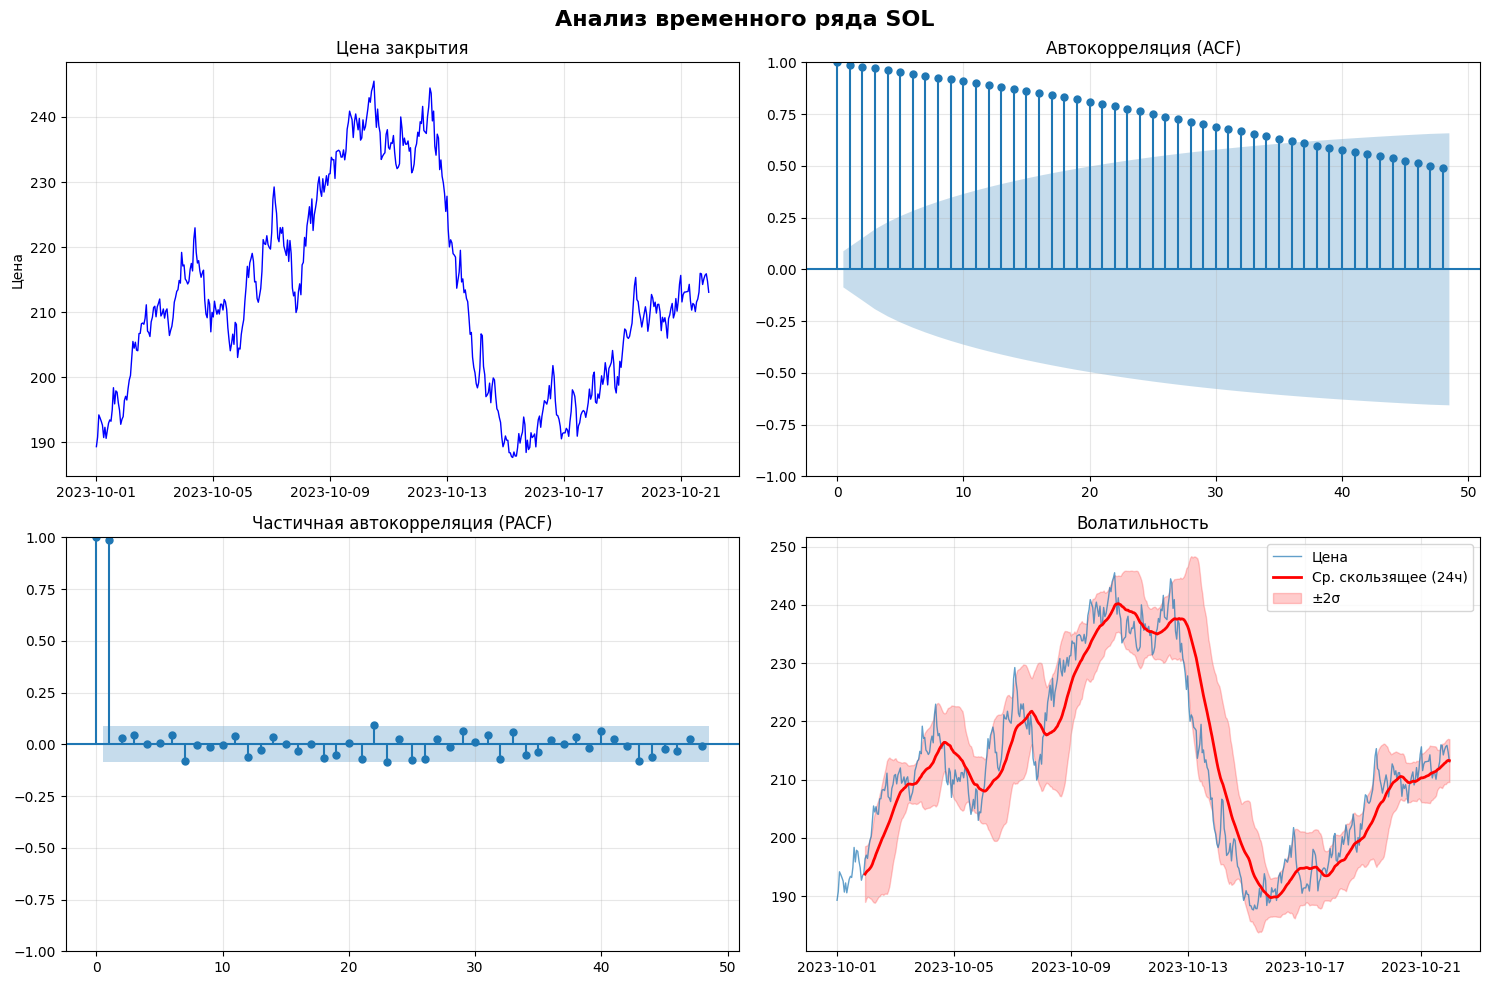


АНАЛИЗ СТАЦИОНАРНОСТИ И ПАРАМЕТРОВ
Тест Дики-Фуллера: p-value = 0.351410
Стационарность: НЕТ


In [34]:
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("КОМПЛЕКСНЫЙ АНАЛИЗ ВРЕМЕННОГО РЯДА ДЛЯ ARIMA")

# Подготовка данных
ts_data = crypto_final.set_index('timestamp')['close'].sort_index()
ts_data = ts_data.asfreq('h')

print(f"Данные: {len(ts_data)} записей, период {ts_data.index.min()} до {ts_data.index.max()}")

# Визуальный анализ
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Анализ временного ряда {selected_asset}', fontsize=16, fontweight='bold')

# 1. Исходный ряд
axes[0, 0].plot(ts_data.index, ts_data.values, linewidth=1, color='blue')
axes[0, 0].set_title('Цена закрытия')
axes[0, 0].set_ylabel('Цена')
axes[0, 0].grid(True, alpha=0.3)

# 2. ACF
plot_acf(ts_data, ax=axes[0, 1], lags=48, alpha=0.05)
axes[0, 1].set_title('Автокорреляция (ACF)')
axes[0, 1].grid(True, alpha=0.3)

# 3. PACF
plot_pacf(ts_data, ax=axes[1, 0], lags=48, alpha=0.05, method='ywm')
axes[1, 0].set_title('Частичная автокорреляция (PACF)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Волатильность
rolling_mean = ts_data.rolling(24).mean()
rolling_std = ts_data.rolling(24).std()

axes[1, 1].plot(ts_data.index, ts_data.values, label='Цена', alpha=0.7, linewidth=1)
axes[1, 1].plot(rolling_mean.index, rolling_mean.values, label='Ср. скользящее (24ч)', color='red', linewidth=2)
axes[1, 1].fill_between(rolling_std.index, rolling_mean - 2*rolling_std, rolling_mean + 2*rolling_std,
                       alpha=0.2, color='red', label='±2σ')
axes[1, 1].set_title('Волатильность')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Анализ стационарности и параметров
print("\nАНАЛИЗ СТАЦИОНАРНОСТИ И ПАРАМЕТРОВ")

# Тест Дики-Фуллера
result = adfuller(ts_data.dropna())
is_stationary = result[1] <= 0.05

print(f"Тест Дики-Фуллера: p-value = {result[1]:.6f}")
print(f"Стационарность: {'ДА' if is_stationary else 'НЕТ'}")

# Анализ ACF/PACF для определения p и q
acf_vals = acf(ts_data, nlags=48, fft=True)
pacf_vals = pacf(ts_data, nlags=48, method='ywm')

Тест Дики-Фуллера показал, что зависисоть не стационарная, то есть имеется тренд, и лучше перейти к SARIMA для учета сезонности. Но мы посмотрим и сравним работу ARIMA с подобранными параметрами и с автопараметрами

СРАВНЕНИЕ ARIMA МОДЕЛЕЙ
Данные: train=432, test=72
Автоподбор: ARIMA(0,1,0)
ARIMA(22,0,23) обучена | AIC: 1867.66
ARIMA(0,1,0) обучена | AIC: 1831.09


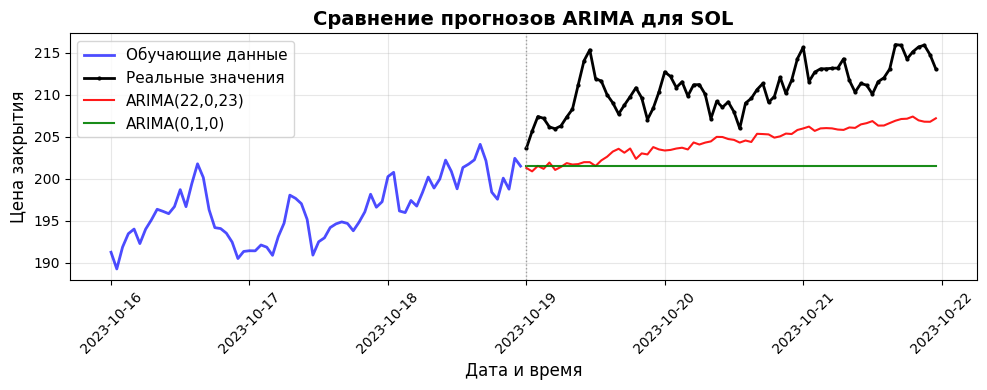


СРАВНЕНИЕ МЕТРИК:

ARIMA(22,0,23):
• MAE:  6.364531
• MSE:  45.22710461
• MAPE: 3.01%
• Точность: 97.0%

ARIMA(0,1,0):
• MAE:  9.286092
• MSE:  94.15125376
• MAPE: 4.39%
• Точность: 95.6%


In [42]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, acf, pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
import numpy as np

print("СРАВНЕНИЕ ARIMA МОДЕЛЕЙ")

# Подготовка данных
ts_data = crypto_final.set_index('timestamp')['close'].sort_index().asfreq('h')

# Разделение на train/test
test_days = 3
train_size = len(ts_data) - test_days * 24
train_data = ts_data.iloc[:train_size]
test_data = ts_data.iloc[train_size:]

print(f"Данные: train={len(train_data)}, test={len(test_data)}")

# Упрощенная функция автоподбора параметров
def find_arima_params(train_data):
    """Автоподбор параметров ARIMA"""
    # Определяем d
    d = 0
    result = adfuller(train_data.dropna())
    if result[1] > 0.05:
        d = 1

    # Определяем p и q (упрощенная версия)
    stationary_data = train_data.diff(d).dropna() if d > 0 else train_data

    acf_vals = acf(stationary_data, nlags=10, fft=True)
    pacf_vals = pacf(stationary_data, nlags=10, method='ywm')

    # Простой подбор p и q
    p = min(3, sum(abs(pacf_vals[1:6]) > 0.15))
    q = min(3, sum(abs(acf_vals[1:6]) > 0.15))

    print(f"Автоподбор: ARIMA({p},{d},{q})")
    return p, d, q

# Обучаем две модели
orders = [(22, 0, 23)]  # Первая модель

# Автоподбор для второй модели
p_auto, d_auto, q_auto = find_arima_params(train_data)
orders.append((p_auto, d_auto, q_auto))

forecasts = []

for i, (p, d, q) in enumerate(orders):
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore") # Чтоб не ругалась
        model = ARIMA(train_data, order=(p, d, q))
        fitted_model = model.fit()

        forecast = fitted_model.forecast(steps=len(test_data))
        forecast_series = pd.Series(forecast, index=test_data.index)

        forecasts.append(forecast_series)

        print(f"ARIMA({p},{d},{q}) обучена | AIC: {fitted_model.aic:.2f}")

# ОБЪЕДИНЕННАЯ ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(10, 4))

# Обучающие данные (последние 72 часа)
plt.plot(train_data.index[-72:], train_data.values[-72:],
        label='Обучающие данные', color='blue', alpha=0.7, linewidth=2)

# Реальные значения теста
plt.plot(test_data.index, test_data.values,
        label='Реальные значения', color='black', linewidth=2, marker='o', markersize=2)

# Прогнозы обеих моделей
colors = ['red', 'green']
linestyles = ['-', '-']
model_names = [f'ARIMA(22,0,23)', f'ARIMA({p_auto},{d_auto},{q_auto})']

for i, (forecast_series, color, linestyle, name) in enumerate(zip(forecasts, colors, linestyles, model_names)):
    plt.plot(forecast_series.index, forecast_series.values,
            label=name, color=color, linewidth=1.5, linestyle=linestyle, alpha=0.9)

plt.title(f'Сравнение прогнозов ARIMA для {selected_asset}', fontsize=14, fontweight='bold')
plt.ylabel('Цена закрытия', fontsize=12)
plt.xlabel('Дата и время', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Добавляем вертикальную линию разделения train/test
split_point = test_data.index[0]
plt.axvline(x=split_point, color='gray', linestyle=':', alpha=0.7, linewidth=1)

plt.tight_layout()
plt.show()

# Сравнение метрик
print("\nСРАВНЕНИЕ МЕТРИК:")
for i, (forecast_series, (p, d, q)) in enumerate(zip(forecasts, orders)):
    mae = mean_absolute_error(test_data, forecast_series)
    mse = mean_squared_error(test_data, forecast_series)
    mape = np.mean(np.abs((test_data - forecast_series) / test_data)) * 100

    print(f"\nARIMA({p},{d},{q}):")
    print(f"• MAE:  {mae:.6f}")
    print(f"• MSE:  {mse:.8f}")
    print(f"• MAPE: {mape:.2f}%")
    print(f"• Точность: {100 - mape:.1f}%")

ARIMA(0,1,0) слишком примитивна для крипторынка. Нужны более сложные параметры, чтобы уловить волатильность и циклы

Предсказание 2

**SARIMA**


ОПТИМИЗИРОВАННАЯ МОДЕЛЬ SARIMA

🔍 АНАЛИЗ СЕЗОННОСТИ


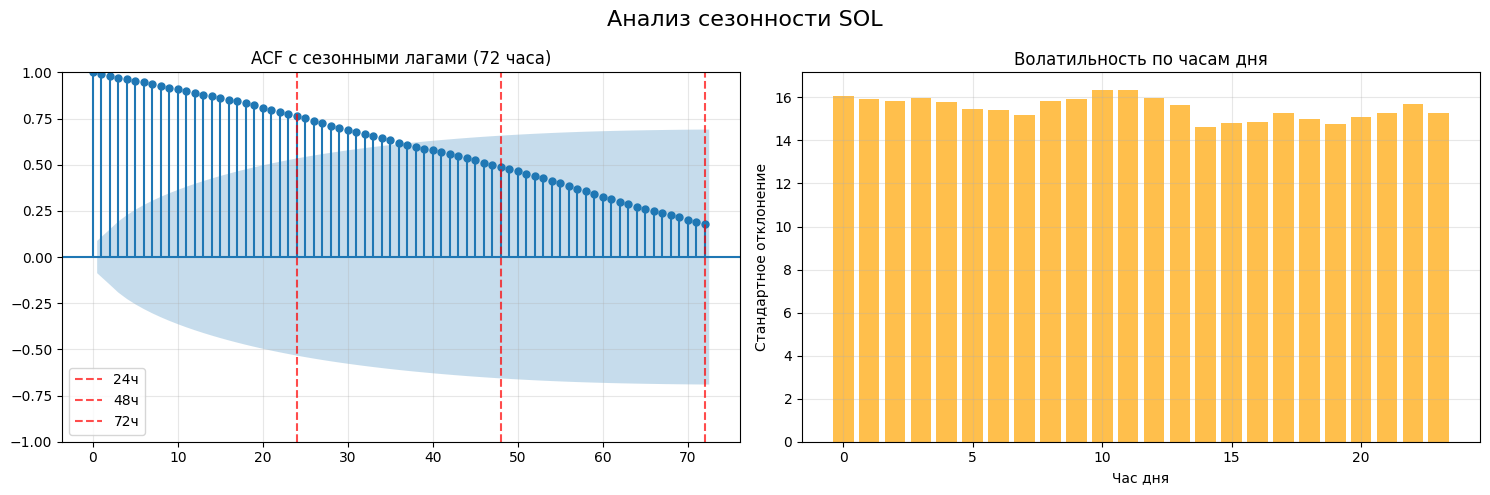

✅ ВЫВОД: Используем суточную сезонность (24ч) - оптимально для крипторынка

ОБУЧЕНИЕ SARIMA МОДЕЛИ
🔧 Обучение SARIMA(2,1,2)(1,1,1,24)...
SARIMA(2,1,2)(1,1,1,24) обучена
   AIC: 1674.54

СРАВНЕНИЕ SARIMA С ARIMA


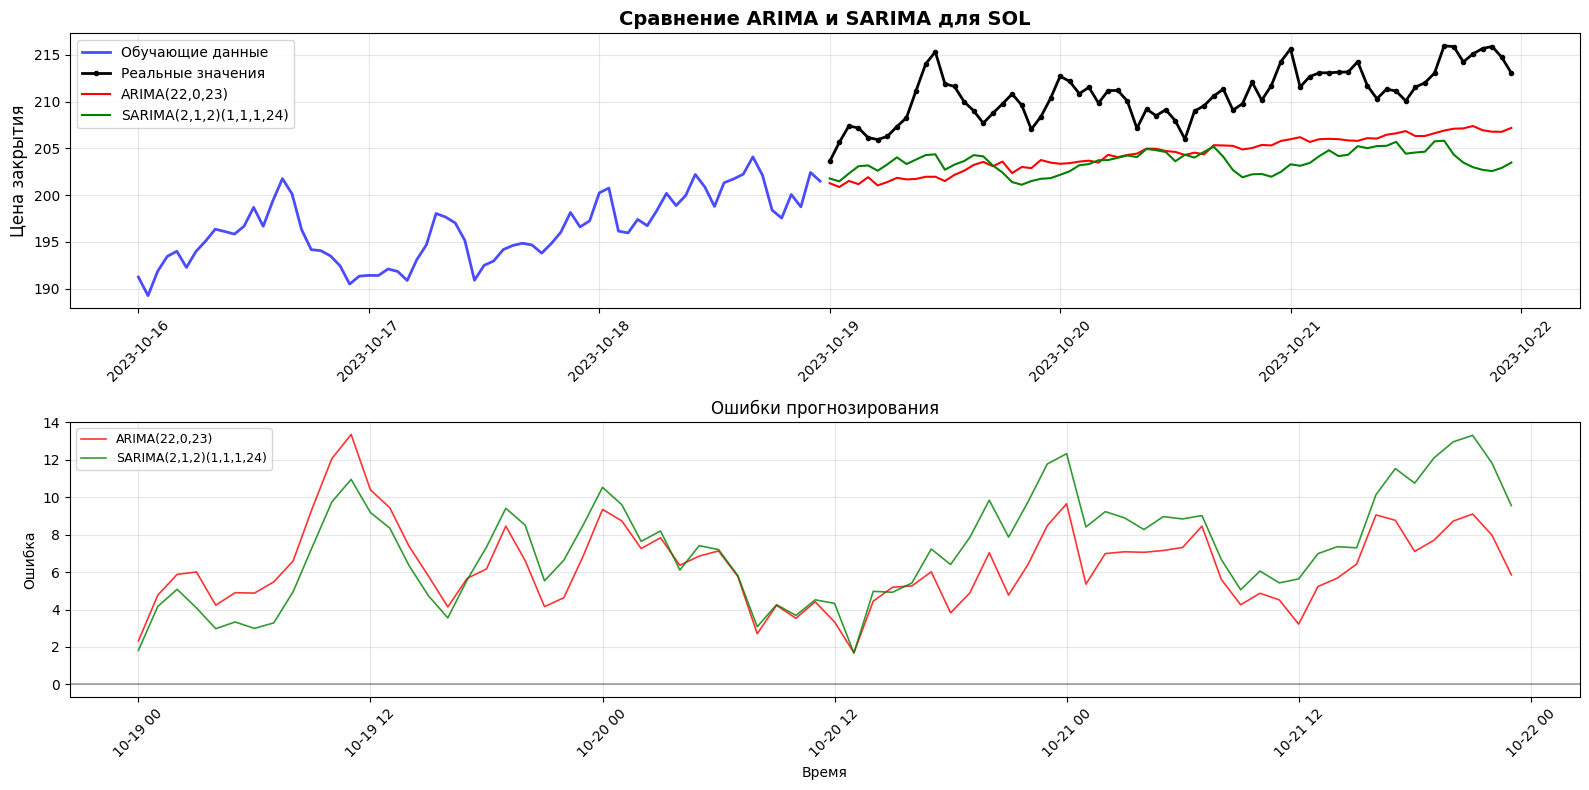


МЕТРИКИ КАЧЕСТВА:

ARIMA(22,0,23):
• MAE:  6.364531
• MSE:  45.22710461
• MAPE: 3.01%
• Точность: 97.0%

SARIMA(2,1,2)(1,1,1,24):
• MAE:  7.239068
• MSE:  60.13478367
• MAPE: 3.42%
• Точность: 96.6%


In [49]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

print("ОПТИМИЗИРОВАННАЯ МОДЕЛЬ SARIMA")

# Анализ сезонности
print("\n🔍 АНАЛИЗ СЕЗОННОСТИ")

# Декомпозиция временного ряда
decomposition = seasonal_decompose(ts_data, model='additive', period=24)

# ИСПРАВЛЕНИЕ: создаем правильную сетку графиков 1x2 вместо 2x2
fig, axes = plt.subplots(1, 2, figsize=(15, 5))  # Изменено на 1x2
fig.suptitle(f'Анализ сезонности {selected_asset}', fontsize=16)

# ACF с сезонными лагами (теперь axes[0] вместо axes[1,0])
plot_acf(ts_data, ax=axes[0], lags=72, alpha=0.05)  # Исправлен индекс
axes[0].set_title('ACF с сезонными лагами (72 часа)')
axes[0].axvline(x=24, color='red', linestyle='--', alpha=0.7, label='24ч')
axes[0].axvline(x=48, color='red', linestyle='--', alpha=0.7, label='48ч')
axes[0].axvline(x=72, color='red', linestyle='--', alpha=0.7, label='72ч')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Волатильность по часам (теперь axes[1] вместо axes[1,1])
ts_data_df = ts_data.reset_index()
ts_data_df['hour'] = ts_data_df['timestamp'].dt.hour
hourly_volatility = ts_data_df.groupby('hour')['close'].std()

axes[1].bar(hourly_volatility.index, hourly_volatility.values, alpha=0.7, color='orange')  # Исправлен индекс
axes[1].set_title('Волатильность по часам дня')
axes[1].set_xlabel('Час дня')
axes[1].set_ylabel('Стандартное отклонение')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ ВЫВОД: Используем суточную сезонность (24ч) - оптимально для крипторынка")

# ОБУЧЕНИЕ ОДНОЙ SARIMA МОДЕЛИ
print("\nОБУЧЕНИЕ SARIMA МОДЕЛИ")

# Одна оптимальная модель вместо двух
sarima_order = (2, 1, 2, 1, 1, 1, 24)
p, d, q, P, D, Q, s = sarima_order

print(f"🔧 Обучение SARIMA({p},{d},{q})({P},{D},{Q},{s})...")

with warnings.catch_warnings():
    warnings.filterwarnings("ignore")

    model = SARIMAX(
        train_data,
        order=(p, d, q),
        seasonal_order=(P, D, Q, s),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(disp=False)
    sarima_forecast = fitted_model.forecast(steps=len(test_data))
    sarima_forecast_series = pd.Series(sarima_forecast, index=test_data.index)

    print(f"SARIMA({p},{d},{q})({P},{D},{Q},{s}) обучена")
    print(f"   AIC: {fitted_model.aic:.2f}")

# Сравнение с ARIMA
print("\nСРАВНЕНИЕ SARIMA С ARIMA")

# Берем лучшую ARIMA модель
best_arima_forecast = forecasts[0]

# Визуализация сравнения
plt.figure(figsize=(16, 8))

# Основной график прогнозов
plt.subplot(2, 1, 1)
plt.plot(train_data.index[-72:], train_data.values[-72:],
        label='Обучающие данные', color='blue', alpha=0.7, linewidth=2)
plt.plot(test_data.index, test_data.values,
        label='Реальные значения', color='black', linewidth=2, marker='o', markersize=3)

# Прогнозы моделей
plt.plot(best_arima_forecast.index, best_arima_forecast.values,
        label=f'ARIMA(22,0,23)', color='red', linewidth=1.5, linestyle='-')

plt.plot(sarima_forecast_series.index, sarima_forecast_series.values,
        label=f'SARIMA({p},{d},{q})({P},{D},{Q},{s})',
        color='green', linewidth=1.5, linestyle='-')

plt.title(f'Сравнение ARIMA и SARIMA для {selected_asset}', fontsize=14, fontweight='bold')
plt.ylabel('Цена закрытия', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# График ошибок
plt.subplot(2, 1, 2)
arima_error = test_data - best_arima_forecast
sarima_error = test_data - sarima_forecast_series

plt.plot(arima_error.index, arima_error.values,
        label='ARIMA(22,0,23)', color='red', alpha=0.8, linewidth=1.2)
plt.plot(sarima_error.index, sarima_error.values,
        label=f'SARIMA({p},{d},{q})({P},{D},{Q},{s})',
        color='green', alpha=0.8, linewidth=1.2)

plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.title('Ошибки прогнозирования', fontsize=12)
plt.ylabel('Ошибка', fontsize=10)
plt.xlabel('Время', fontsize=10)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Сравнение метрик
print("\nМЕТРИКИ КАЧЕСТВА:")

models_forecasts = [best_arima_forecast, sarima_forecast_series]
models_names = ['ARIMA(22,0,23)', f'SARIMA({p},{d},{q})({P},{D},{Q},{s})']

for forecast, name in zip(models_forecasts, models_names):
    mae = mean_absolute_error(test_data, forecast)
    mse = mean_squared_error(test_data, forecast)
    mape = np.mean(np.abs((test_data - forecast) / test_data)) * 100

    print(f"\n{name}:")
    print(f"• MAE:  {mae:.6f}")
    print(f"• MSE:  {mse:.8f}")
    print(f"• MAPE: {mape:.2f}%")
    print(f"• Точность: {100 - mape:.1f}%")

Рассматривая график ACF с сезонными лагами я понял, что сезонность напрочь отсутствует либо, что более вероятно, график на этом масштабе (3 недели) не показвает ее. На сезоностти в 168 чсов (1 неделя) нагрузка и расчетное время увеличивается в O^3 из-за разросшейся матрицы учитваемых лагов (памяти). Я подозреваю 2-недельную сезонность и глобально нижний тренд, но в более глубокий анализ не полезу. Решение можно былобы найти использовав скажем цену криптовалюты на конец каждого дня (Данных было бы меньше, лагов меньше, расчеты быстрее)

Предсказание 3

**RANDOM FOREST**

🌲 RANDOM FOREST: ПРОГНОЗ ИЗМЕНЕНИЙ С КОРРЕКТНЫМИ ВЕСАМИ
Данные: train=407, test=72
Среднее изменение в обучающих данных: 0.0100%


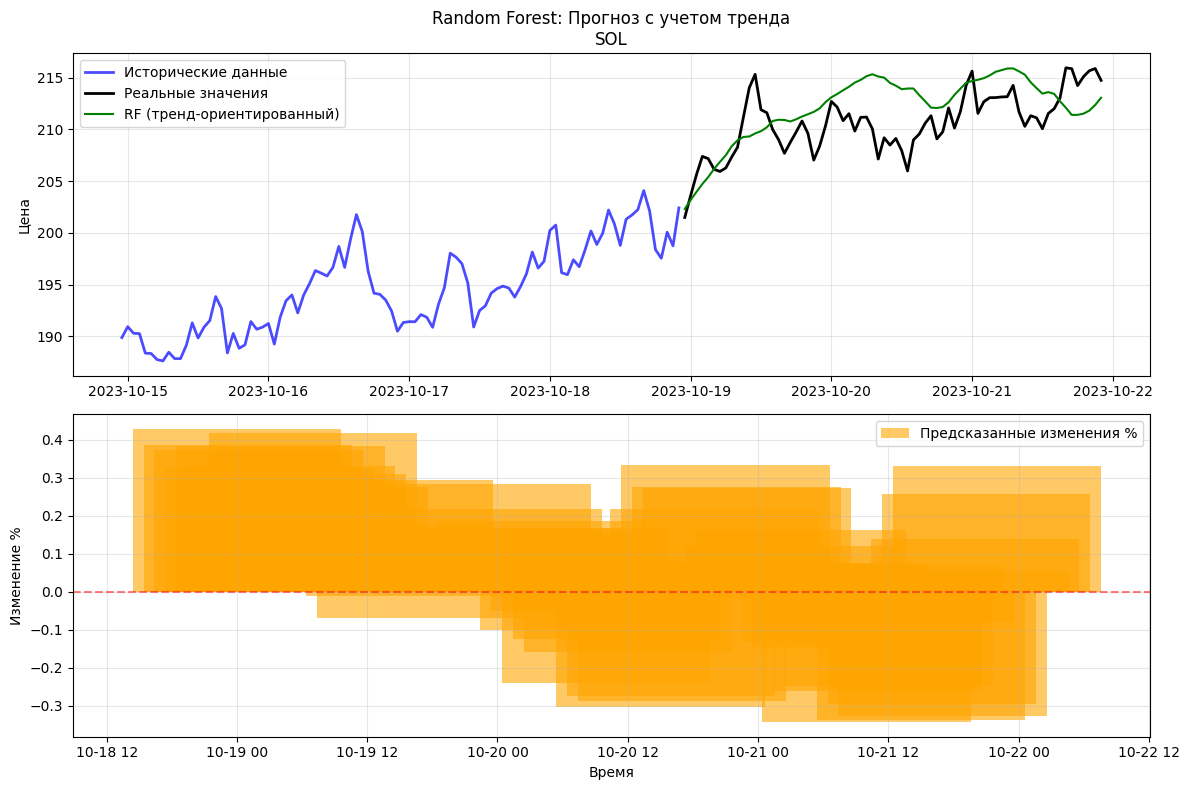

📈 Исторический тренд (24ч): 2.62%
📊 MAPE: 1.32%

🔝 Важные признаки для тренда:
         feature  importance
5    momentum_6h    0.126879
6   momentum_24h    0.124161
4         lag_24    0.121132
3         lag_12    0.096412
1          lag_2    0.083859
11      hour_sin    0.077251


In [71]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

print("🌲 RANDOM FOREST: ПРОГНОЗ ИЗМЕНЕНИЙ С КОРРЕКТНЫМИ ВЕСАМИ")

def create_trend_features(df):
    """Признаки с акцентом на тренд"""
    df = df.copy()

    # Лаги
    for lag in [1, 2, 6, 12, 24]:
        df[f'lag_{lag}'] = df['close'].shift(lag)

    # 🔥 ПРИЗНАКИ ТРЕНДА
    df['momentum_6h'] = (df['close'] / df['close'].shift(6) - 1) * 100  # 6-часовой тренд в %
    df['momentum_24h'] = (df['close'] / df['close'].shift(24) - 1) * 100  # 24-часовой тренд

    # Скользящие средние для определения направления
    df['sma_6'] = df['close'].rolling(6).mean()
    df['sma_24'] = df['close'].rolling(24).mean()
    df['above_sma_6'] = (df['close'] > df['sma_6']).astype(int)
    df['above_sma_24'] = (df['close'] > df['sma_24']).astype(int)

    # Временные признаки
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour/24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour/24)

    # 🔥 ЦЕЛЕВАЯ ПЕРЕМЕННАЯ: изменение в следующий час (в %)
    df['target_change_pct'] = (df['close'].shift(-1) / df['close'] - 1) * 100

    return df

def trend_aware_recursive_forecast(model, last_row, feature_columns, last_price, steps=72):
    """Прогноз с учетом тренда"""
    predictions = []
    current_features = last_row.copy()
    current_price = last_price

    for step in range(steps):
        current_df = pd.DataFrame([current_features.values], columns=feature_columns)

        # 🔥 ПРЕДСКАЗЫВАЕМ ИЗМЕНЕНИЕ В %
        change_pct = model.predict(current_df)[0]

        # ВЫЧИСЛЯЕМ НОВУЮ ЦЕНУ
        new_price = current_price * (1 + change_pct / 100)
        predictions.append(new_price)

        # 🔄 ОБНОВЛЯЕМ ПРИЗНАКИ С СОХРАНЕНИЕМ ТРЕНДА
        if step < steps - 1:
            current_features = current_features.copy()
            current_price = new_price

            # ОБНОВЛЯЕМ ЛАГИ (сохраняем тренд)
            current_features['lag_1'] = current_price
            current_features['lag_2'] = current_features['lag_1']
            current_features['lag_6'] = current_features['lag_2']
            current_features['lag_12'] = current_features['lag_6']
            current_features['lag_24'] = current_features['lag_12']

            # 🔥 ОБНОВЛЯЕМ ПРИЗНАКИ ТРЕНДА
            current_features['momentum_6h'] = (current_price / current_features['lag_6'] - 1) * 100
            current_features['momentum_24h'] = (current_price / current_features['lag_24'] - 1) * 100

            # Обновляем скользящие средние
            current_features['sma_6'] = (current_features['sma_6'] * 0.8 + current_price * 0.2)
            current_features['sma_24'] = (current_features['sma_24'] * 0.9 + current_price * 0.1)
            current_features['above_sma_6'] = 1 if current_price > current_features['sma_6'] else 0
            current_features['above_sma_24'] = 1 if current_price > current_features['sma_24'] else 0

            # Обновляем время
            hour_rad = ((step + 1) % 24) * 2 * np.pi / 24
            current_features['hour_sin'] = np.sin(hour_rad)
            current_features['hour_cos'] = np.cos(hour_rad)

    return np.array(predictions)

# Подготовка данных
ts_data = crypto_final.set_index('timestamp')['close'].sort_index().asfreq('h')
df = create_trend_features(ts_data.to_frame())
df_clean = df.dropna()

# Разделение
test_hours = 72
train_data = df_clean.iloc[:-test_hours]
test_data = df_clean.iloc[-test_hours:]

# Признаки и целевая переменная
feature_columns = [col for col in train_data.columns if col not in ['close', 'target_change_pct']]
X_train = train_data[feature_columns]
y_train = train_data['target_change_pct']  # Изменение в %

print(f"Данные: train={len(X_train)}, test={len(test_data)}")
print(f"Среднее изменение в обучающих данных: {y_train.mean():.4f}%")

# 🔥 МОДЕЛЬ С АКЦЕНТОМ НА ТРЕНД
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,  # Больше глубина для улавливания трендов
    min_samples_split=3,
    min_samples_leaf=1,
    max_features=0.7,
    random_state=42,
    n_jobs=-1
)

# Обучение
model.fit(X_train, y_train)

# Прогноз
last_train_row = train_data[feature_columns].iloc[-1]
last_known_price = train_data['close'].iloc[-1]

rf_predictions = trend_aware_recursive_forecast(
    model, last_train_row, feature_columns, last_known_price, test_hours
)
rf_forecast = pd.Series(rf_predictions, index=test_data.index)

# 📊 ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(train_data.index[-96:], train_data['close'].values[-96:],
         label='Исторические данные', color='blue', alpha=0.7, linewidth=2)
plt.plot(test_data.index, test_data['close'].values,
         label='Реальные значения', color='black', linewidth=2)
plt.plot(rf_forecast.index, rf_forecast.values,
         label='RF (тренд-ориентированный)', color='green', linewidth=1.5)
plt.title(f'Random Forest: Прогноз с учетом тренда\n{selected_asset}')
plt.ylabel('Цена')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
# Показываем предсказанные изменения
predicted_changes = (rf_forecast.pct_change() * 100).fillna(0)
plt.bar(predicted_changes.index, predicted_changes.values,
        alpha=0.6, color='orange', label='Предсказанные изменения %')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
plt.ylabel('Изменение %')
plt.xlabel('Время')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Метрики
mape = np.mean(np.abs((test_data['close'] - rf_forecast) / test_data['close'])) * 100

# Анализ тренда
initial_trend = (train_data['close'].iloc[-1] / train_data['close'].iloc[-24] - 1) * 100
print(f"📈 Исторический тренд (24ч): {initial_trend:.2f}%")
print(f"📊 MAPE: {mape:.2f}%")

# Важность признаков
importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n🔝 Важные признаки для тренда:")
print(importance.head(6))

🌲 RANDOM FOREST: ОПТИМИЗИРОВАННЫЙ РЕКУРРЕНТНЫЙ ПРОГНОЗ
Данные: train=408, test=72


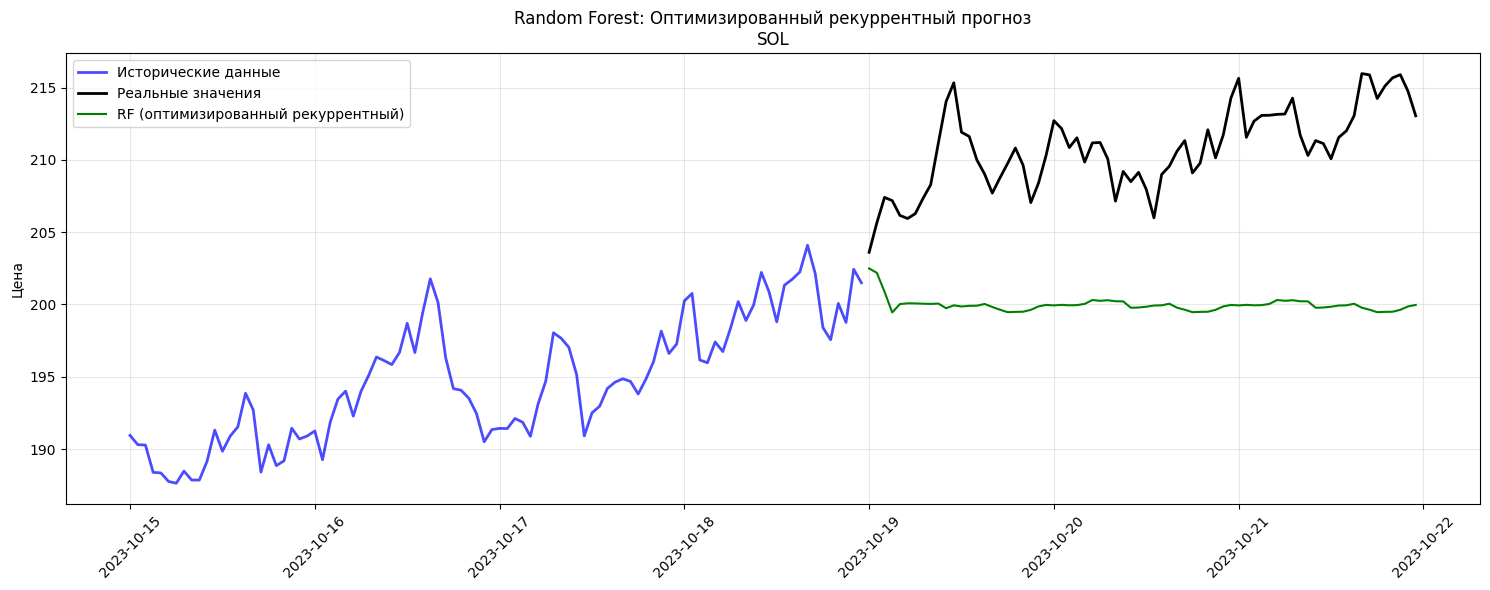

📊 MAPE: 5.11%
📈 Волатильность прогноза: 0.0014
📈 Волатильность реальная: 0.0076

🔝 Топ-5 важных признаков:
          feature  importance
0           lag_1    0.711547
5  rolling_mean_6    0.192996
1           lag_2    0.086431
7        hour_sin    0.001681
3          lag_12    0.001600


In [68]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

print("🌲 RANDOM FOREST: ОПТИМИЗИРОВАННЫЙ РЕКУРРЕНТНЫЙ ПРОГНОЗ")

def create_robust_features(df):
    """Признаки, устойчивые к накоплению ошибки"""
    df = df.copy()

    # Разнообразные лаги
    for lag in [1, 2, 6, 12, 24]:  # Добавили lag_1 и больше горизонтов
        df[f'lag_{lag}'] = df['close'].shift(lag)

    # Скользящие статистики
    df['rolling_mean_6'] = df['close'].rolling(6).mean()
    df['rolling_mean_24'] = df['close'].rolling(24).mean()

    # Временные признаки
    df['hour_sin'] = np.sin(2 * np.pi * df.index.hour/24)
    df['hour_cos'] = np.cos(2 * np.pi * df.index.hour/24)
    df['day_of_week'] = df.index.dayofweek

    return df

def optimized_recursive_forecast(model, last_row, feature_columns, steps=72):
    """Рекуррентный прогноз с оптимизированным затуханием"""
    predictions = []
    current_features = last_row.copy()

    for step in range(steps):
        # Преобразуем в DataFrame с правильными feature names
        current_df = pd.DataFrame([current_features.values], columns=feature_columns)

        # Предсказываем на 1 шаг
        pred = model.predict(current_df)[0]
        predictions.append(pred)

        # 🔄 ОПТИМИЗИРОВАННОЕ ОБНОВЛЕНИЕ ПРИЗНАКОВ
        if step < steps - 1:
            current_features = current_features.copy()

            # МЕНЕЕ АГРЕССИВНОЕ ЗАТУХАНИЕ
            # Лаги сдвигаются с меньшим затуханием
            current_features['lag_24'] = current_features['lag_12'] * 0.95  # было 0.8
            current_features['lag_12'] = current_features['lag_6'] * 0.97   # было 0.9
            current_features['lag_6'] = current_features['lag_2'] * 0.98    # было 0.9
            current_features['lag_2'] = current_features['lag_1'] * 0.99    # было 0.8
            current_features['lag_1'] = pred  # Новейшее значение

            # Скользящие средние адаптируются медленнее
            current_features['rolling_mean_6'] = (current_features['rolling_mean_6'] * 0.7 + pred * 0.3)
            current_features['rolling_mean_24'] = (current_features['rolling_mean_24'] * 0.9 + pred * 0.1)

            # Временные признаки обновляем для следующего часа
            next_hour = (current_features['hour_sin'], current_features['hour_cos'])
            # Простая ротация часов (упрощенно)
            hour_rad = (step % 24) * 2 * np.pi / 24
            current_features['hour_sin'] = np.sin(hour_rad)
            current_features['hour_cos'] = np.cos(hour_rad)

    return np.array(predictions)

# Подготовка данных
ts_data = crypto_final.set_index('timestamp')['close'].sort_index().asfreq('h')
df = create_robust_features(ts_data.to_frame())
df_clean = df.dropna()

# Разделение
test_hours = 72
train_data = df_clean.iloc[:-test_hours]
test_data = df_clean.iloc[-test_hours:]

# Признаки
feature_columns = [col for col in train_data.columns if col != 'close']
X_train = train_data[feature_columns]
y_train = train_data['close']

print(f"Данные: train={len(X_train)}, test={len(test_data)}")

# 🔧 ОПТИМИЗИРОВАННАЯ МОДЕЛЬ - МЕНЬШЕ РЕГУЛЯРИЗАЦИИ
model = RandomForestRegressor(
    n_estimators=150,       # Больше деревьев для сложных паттернов
    max_depth=12,           # Больше глубина для улавливания зависимостей
    min_samples_split=5,    # Меньше ограничений
    min_samples_leaf=2,     # Меньше ограничений
    max_features=0.8,       # Больше признаков
    random_state=42,
    n_jobs=-1
)

# Обучение
model.fit(X_train, y_train)

# Прогноз
last_train_row = train_data[feature_columns].iloc[-1]
rf_predictions = optimized_recursive_forecast(model, last_train_row, feature_columns, test_hours)
rf_forecast = pd.Series(rf_predictions, index=test_data.index)

# 📊 ВИЗУАЛИЗАЦИЯ
plt.figure(figsize=(15, 6))

plt.plot(train_data.index[-96:], train_data['close'].values[-96:],
         label='Исторические данные', color='blue', alpha=0.7, linewidth=2)
plt.plot(test_data.index, test_data['close'].values,
         label='Реальные значения', color='black', linewidth=2)
plt.plot(rf_forecast.index, rf_forecast.values,
         label='RF (оптимизированный рекуррентный)', color='green', linewidth=1.5)

plt.title(f'Random Forest: Оптимизированный рекуррентный прогноз\n{selected_asset}')
plt.ylabel('Цена')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Метрики
mape = np.mean(np.abs((test_data['close'] - rf_forecast) / test_data['close'])) * 100
print(f"📊 MAPE: {mape:.2f}%")

# Анализ волатильности прогноза
forecast_volatility = rf_forecast.pct_change().std()
real_volatility = test_data['close'].pct_change().std()
print(f"📈 Волатильность прогноза: {forecast_volatility:.4f}")
print(f"📈 Волатильность реальная: {real_volatility:.4f}")

# Важность признаков
importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n🔝 Топ-5 важных признаков:")
print(importance.head(5))

Так как модель может предсказывать только на 1 шаг впреде, то еть она не рекурентная, то она либо "подсматривает" (использнает лаги в которых содеждится информация о следующем шаге и строит прогноз на информации из будущего, что "не чесно"), либо уходит в прямую линию (то есть ничего не предсказывает)

Решение - добавить информация о прошлом